In [ ]:
# @title 📦 Cell 1 — Install Dependencies
!pip install google-api-python-client -q
!pip install pandas -q
!pip install groq -q
!pip install matplotlib -q

print('✅ All dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 6.6 MB/s eta 0:00:00
✅ All dependencies installed.


In [ ]:
# @title ⚙️ Cell 2 — Imports
import warnings
warnings.filterwarnings('ignore')

import re
import time
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from groq import Groq
from googleapiclient.discovery import build
from googleapiclient.errors import HttpError

print('✅ All libraries imported.')

✅ All libraries imported.


In [ ]:
# @title 🔑 Cell 3 — YouTube API Key
YOUTUBE_API_KEY = ''

youtube = build('youtube', 'v3', developerKey=YOUTUBE_API_KEY)
print('✅ YouTube client initialized.')

✅ YouTube client initialized.


In [ ]:
# @title 🤖 Cell 4 — Groq API Key & Test
GROQ_API_KEY = ''
groq_client = Groq(api_key=GROQ_API_KEY)

def call_groq(prompt, max_tokens=800):
    """Call Groq Llama 3.1 8B."""
    response = groq_client.chat.completions.create(
        model='llama-3.1-8b-instant',
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_tokens,
        temperature=0.0
    )
    return response.choices[0].message.content.strip()

# Connection test
try:
    result = call_groq("Reply with only the word: working", max_tokens=5)
    print(f'✅ Groq connected: "{result}"')
except Exception as e:
    print(f'❌ Groq connection failed: {e}')

✅ Groq connected: "working"


In [ ]:
# @title 🎬 Cell 5 — Video Links & Settings

video_links = [
    "https://youtu.be/1qvWYBNCXDQ?si=OKY-SZIPcS0N1pCb",
    "https://youtu.be/zW0Kn0fCWY0?si=6bt-leGsIXhV5oNh",
    "https://youtu.be/MUiltjUBDdI?si=6ioFsDcL2qa6SSd1",
]

MAX_COMMENTS         = 500  # comments to fetch per video
SENTIMENT_BATCH_SIZE = 20   # comments per Groq sentiment call
THEME_BATCH_SIZE     = 30   # comments per Groq theme call
SLEEP_BETWEEN_CALLS  = 3    # seconds between Groq calls

print(f'✅ {len(video_links)} video(s) queued. Max comments per video: {MAX_COMMENTS}')

✅ 3 video(s) queued. Max comments per video: 500


In [ ]:
# @title 🛠️ Cell 6 — All Helper Functions

# ── YouTube ───────────────────────────────────────────────────
def extract_video_id(url):
    match = re.search(r'(?:v=|\/)([0-9A-Za-z_-]{11}).*', url)
    return match.group(1) if match else None


def get_comments(video_id, max_comments=500):
    comments = []
    try:
        request = youtube.commentThreads().list(
            part='snippet', videoId=video_id, maxResults=100
        )
        while request and len(comments) < max_comments:
            response = request.execute()
            for item in response['items']:
                comments.append(
                    item['snippet']['topLevelComment']['snippet']['textDisplay']
                )
            request = youtube.commentThreads().list_next(request, response)
    except HttpError as e:
        print(f'  ❌ API Error: {e}')
    return comments[:max_comments]


# ── Groq Sentiment Classification ────────────────────────────
def groq_classify_batch(comments_batch):
    """
    Send a batch of comments to Groq.
    Groq classifies each as Positive, Negative, or Neutral.
    Understands sarcasm, Hindi/Hinglish, Indian cultural context.
    Returns list of labels in same order as input.
    """
    numbered = '\n'.join([f'{i+1}. {c[:300]}' for i, c in enumerate(comments_batch)])

    prompt = f"""You are analyzing YouTube comments from an Indian podcast/interview.
These comments may be in English, Hindi, Hinglish, or mixed languages.

Classify each comment as exactly one of: Positive, Negative, or Neutral.

Important rules:
- Sarcasm like "What an era we are living in..." = Negative
- Rhetorical questions like "Why doesn't he speak Hindi?" = Negative
- Cultural criticism like "a non-Indian teaching us our culture" = Negative
- Genuine praise, appreciation, love = Positive
- Suggestions, complaints, disagreements = Negative
- Neutral observations, questions, facts = Neutral

Comments:
{numbered}

Return ONLY a JSON array with one label per comment, in the same order.
Example for 3 comments: ["Positive", "Negative", "Neutral"]
Return ONLY the JSON array, nothing else."""

    for attempt in range(3):
        try:
            raw = call_groq(prompt, max_tokens=200)
            raw = re.sub(r'```json|```', '', raw).strip()
            labels = json.loads(raw)
            # Validate
            valid = {'Positive', 'Negative', 'Neutral'}
            labels = [l if l in valid else 'Neutral' for l in labels]
            # Pad if Groq returned fewer labels than comments
            while len(labels) < len(comments_batch):
                labels.append('Neutral')
            return labels[:len(comments_batch)]
        except json.JSONDecodeError:
            print(f'  ⚠️ JSON parse error attempt {attempt+1}, retrying...')
            time.sleep(3)
        except Exception as e:
            if '429' in str(e):
                print(f'  ⏳ Rate limited, waiting 20s...')
                time.sleep(20)
            else:
                print(f'  ⚠️ Groq error: {e}')
                return ['Neutral'] * len(comments_batch)
    return ['Neutral'] * len(comments_batch)


def classify_all_comments(comments, batch_size=20):
    """Run Groq sentiment classification on all comments in batches."""
    all_labels = []
    total_batches = (len(comments) + batch_size - 1) // batch_size

    for i in range(0, len(comments), batch_size):
        batch = comments[i:i+batch_size]
        batch_num = i // batch_size + 1
        print(f'  → Sentiment batch {batch_num}/{total_batches}...', end=' ')
        labels = groq_classify_batch(batch)
        all_labels.extend(labels)
        pos = labels.count('Positive')
        neg = labels.count('Negative')
        neu = labels.count('Neutral')
        print(f'✅ +{pos} -{neg} ~{neu}')
        time.sleep(SLEEP_BETWEEN_CALLS)

    return all_labels


# ── Groq Theme Clustering ─────────────────────────────────────
def groq_extract_themes_from_batch(comments_batch, sentiment_type):
    """Extract themes from one batch of comments."""
    numbered = '\n'.join([f'{i+1}. {c[:200]}' for i, c in enumerate(comments_batch)])

    prompt = f"""You are analyzing {sentiment_type} YouTube comments from an Indian podcast.

Here are {len(comments_batch)} comments:
{numbered}

Group these into 2-4 themes. For each theme:
- theme_name: short 3-5 word label
- summary: one clear sentence describing what people are saying
- comment_indices: list of comment numbers in this theme (1-based)

Return ONLY valid JSON, no extra text:
[
  {{"theme_name": "...", "summary": "...", "comment_indices": [1, 3, 5]}},
  {{"theme_name": "...", "summary": "...", "comment_indices": [2, 4]}}
]"""

    for attempt in range(3):
        try:
            raw = call_groq(prompt, max_tokens=600)
            raw = re.sub(r'```json|```', '', raw).strip()
            themes = json.loads(raw)
            for theme in themes:
                theme['comments'] = [
                    comments_batch[i-1]
                    for i in theme.get('comment_indices', [])
                    if 0 < i <= len(comments_batch)
                ]
                theme['count'] = len(theme['comments'])
            return themes
        except json.JSONDecodeError:
            print(f'  ⚠️ JSON parse error attempt {attempt+1}, retrying...')
            time.sleep(3)
        except Exception as e:
            if '429' in str(e):
                print(f'  ⏳ Rate limited, waiting 20s...')
                time.sleep(20)
            else:
                print(f'  ⚠️ Theme error: {e}')
                return []
    return []


def groq_merge_themes(all_themes, sentiment_type):
    """Consolidate themes from all batches into 4-8 final themes."""
    theme_summary = '\n'.join([
        f'- {t["theme_name"]}: {t["summary"]} ({t.get("count",0)} comments)'
        for t in all_themes
    ])

    prompt = f"""Consolidate these {sentiment_type} comment themes from a podcast into 4-8 distinct final themes.
Merge similar/overlapping ones and add up their counts.

Input themes:
{theme_summary}

Return ONLY valid JSON, no extra text:
[
  {{"theme_name": "...", "summary": "...", "count": 12}},
  {{"theme_name": "...", "summary": "...", "count": 8}}
]"""

    for attempt in range(3):
        try:
            raw = call_groq(prompt, max_tokens=600)
            raw = re.sub(r'```json|```', '', raw).strip()
            merged = json.loads(raw)
            return sorted(merged, key=lambda x: x.get('count', 0), reverse=True)
        except json.JSONDecodeError:
            print(f'  ⚠️ Merge JSON error attempt {attempt+1}, retrying...')
            time.sleep(3)
        except Exception as e:
            if '429' in str(e):
                print(f'  ⏳ Rate limited, waiting 20s...')
                time.sleep(20)
            else:
                print(f'  ⚠️ Merge error: {e}')
                return all_themes
    return all_themes


def cluster_with_groq(comments, sentiment_type, batch_size=30):
    """Full Groq theme clustering pipeline."""
    comments = list(set(comments))  # deduplicate
    if len(comments) < 5:
        print(f'  ⚠️ Not enough comments to cluster ({len(comments)})')
        return []

    all_themes = []
    total_batches = (len(comments) + batch_size - 1) // batch_size
    print(f'  → Clustering {len(comments)} comments in {total_batches} batches...')

    for i in range(0, len(comments), batch_size):
        batch = comments[i:i+batch_size]
        batch_num = i // batch_size + 1
        print(f'  → Theme batch {batch_num}/{total_batches}...', end=' ')
        themes = groq_extract_themes_from_batch(batch, sentiment_type)
        all_themes.extend(themes)
        print(f'{len(themes)} themes found')
        time.sleep(SLEEP_BETWEEN_CALLS)

    if not all_themes:
        return []

    if total_batches == 1:
        return sorted(all_themes, key=lambda x: x.get('count', 0), reverse=True)

    print(f'  → Merging {len(all_themes)} raw themes...')
    time.sleep(SLEEP_BETWEEN_CALLS)
    return groq_merge_themes(all_themes, sentiment_type)


print('✅ All helper functions defined.')

✅ All helper functions defined.


In [ ]:
# @title 📊 Cell 7 — Main Analysis Loop (Fetch + Groq Sentiment)

episode_results = []
video_data = []

for idx, link in enumerate(video_links):
    print(f'\n🔍 Analyzing Video {idx+1}: {link}')

    video_id = extract_video_id(link)
    if video_id is None:
        print('  ❌ Could not extract video ID. Skipping.')
        continue

    comments = get_comments(video_id, max_comments=MAX_COMMENTS)
    if not comments:
        print('  ⚠️ No comments found. Skipping.')
        continue

    print(f'  → Fetched {len(comments)} comments')
    print(f'  → Running Groq sentiment classification...')

    labels = classify_all_comments(comments, batch_size=SENTIMENT_BATCH_SIZE)

    pos_comments = [c for c, l in zip(comments, labels) if l == 'Positive']
    neg_comments = [c for c, l in zip(comments, labels) if l == 'Negative']
    neu_comments = [c for c, l in zip(comments, labels) if l == 'Neutral']

    total = len(comments)
    pos_pct = round(len(pos_comments) / total * 100, 2)
    neg_pct = round(len(neg_comments) / total * 100, 2)
    neu_pct = round(len(neu_comments) / total * 100, 2)

    print(f'\n  ✅ Final: Positive: {pos_pct}% | Neutral: {neu_pct}% | Negative: {neg_pct}%')

    episode_results.append({
        'Video': f'Video {idx+1}',
        'URL': link,
        'Total Comments': total,
        'Positive %': pos_pct,
        'Neutral %':   neu_pct,
        'Negative %':  neg_pct,
        'Strength-Risk Ratio': round(pos_pct / max(neg_pct, 0.01), 2),
        'Controversy Score':   round(min(pos_pct, neg_pct), 2),
    })

    video_data.append({
        'label': f'Video {idx+1}',
        'url': link,
        'pos_comments': pos_comments,
        'neg_comments': neg_comments,
    })

comparison_df = pd.DataFrame(episode_results)
print('\n✅ Sentiment analysis complete for all videos.')
comparison_df


🔍 Analyzing Video 1: https://youtu.be/1qvWYBNCXDQ?si=OKY-SZIPcS0N1pCb
  → Fetched 242 comments
  → Running Groq sentiment classification...
  → Sentiment batch 1/13... ✅ +8 -6 ~6
  → Sentiment batch 2/13... ✅ +11 -4 ~5
  → Sentiment batch 3/13... ✅ +8 -5 ~7
  → Sentiment batch 4/13... ✅ +7 -7 ~6
  → Sentiment batch 5/13... ✅ +12 -5 ~3
  → Sentiment batch 6/13... ✅ +9 -4 ~7
  → Sentiment batch 7/13... ✅ +13 -3 ~4
  → Sentiment batch 8/13... ✅ +10 -5 ~5
  → Sentiment batch 9/13... ✅ +10 -2 ~8
  → Sentiment batch 10/13... ✅ +11 -4 ~5
  → Sentiment batch 11/13... ✅ +14 -2 ~4
  → Sentiment batch 12/13... ✅ +8 -3 ~9
  → Sentiment batch 13/13... ✅ +1 -1 ~0

  ✅ Final: Positive: 50.41% | Neutral: 28.51% | Negative: 21.07%

🔍 Analyzing Video 2: https://youtu.be/zW0Kn0fCWY0?si=6bt-leGsIXhV5oNh
  → Fetched 261 comments
  → Running Groq sentiment classification...
  → Sentiment batch 1/14... ✅ +5 -11 ~4
  → Sentiment batch 2/14... ✅ +10 -6 ~4
  → Sentiment batch 3/14... ✅ +13 -5 ~2
  → Sentiment 

,Video,URL,Total Comments,Positive %,Neutral %,Negative %,Strength-Risk Ratio,Controversy Score
0,Video 1,https://youtu.be/1qvWYBNCXDQ?si=OKY-SZIPcS0N1pCb,242,50.41,28.51,21.07,2.39,21.07
1,Video 2,https://youtu.be/zW0Kn0fCWY0?si=6bt-leGsIXhV5oNh,261,39.08,23.75,37.16,1.05,37.16
2,Video 3,https://youtu.be/MUiltjUBDdI?si=6ioFsDcL2qa6SSd1,219,46.12,27.85,26.03,1.77,26.03


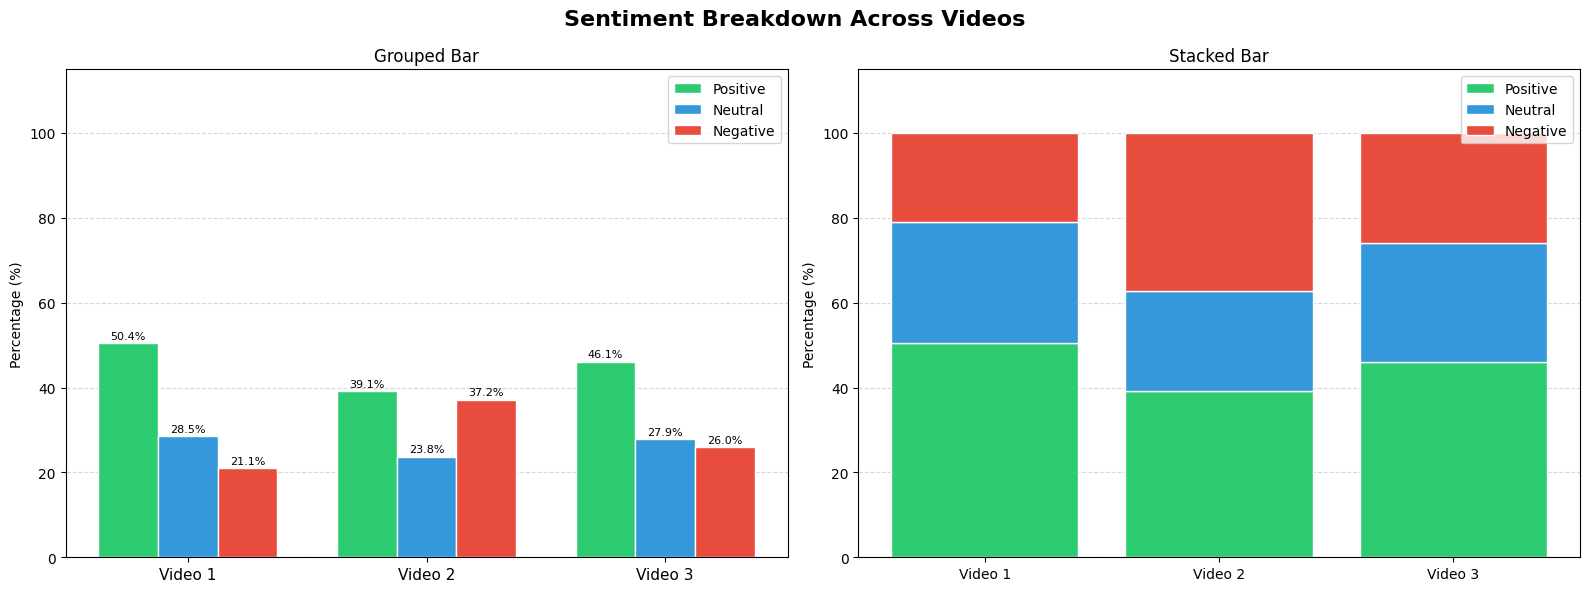

✅ Saved: sentiment_breakdown.png


In [ ]:
# @title 📊 Cell 8 — Visualization: Sentiment Breakdown

labels_x = [r['Video'] for r in episode_results]
pos_vals  = [r['Positive %'] for r in episode_results]
neu_vals  = [r['Neutral %']  for r in episode_results]
neg_vals  = [r['Negative %'] for r in episode_results]
x = np.arange(len(labels_x))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Sentiment Breakdown Across Videos', fontsize=16, fontweight='bold')

ax1 = axes[0]
b1 = ax1.bar(x-width, pos_vals, width, label='Positive', color='#2ecc71', edgecolor='white')
b2 = ax1.bar(x,       neu_vals, width, label='Neutral',  color='#3498db', edgecolor='white')
b3 = ax1.bar(x+width, neg_vals, width, label='Negative', color='#e74c3c', edgecolor='white')
ax1.set_xticks(x); ax1.set_xticklabels(labels_x, fontsize=11)
ax1.set_ylabel('Percentage (%)'); ax1.set_title('Grouped Bar')
ax1.legend(); ax1.set_ylim(0, 115)
ax1.yaxis.grid(True, linestyle='--', alpha=0.5); ax1.set_axisbelow(True)
for bar in [*b1, *b2, *b3]:
    h = bar.get_height()
    if h > 0:
        ax1.text(bar.get_x()+bar.get_width()/2, h+1, f'{h:.1f}%', ha='center', fontsize=8)

ax2 = axes[1]
ax2.bar(labels_x, pos_vals, label='Positive', color='#2ecc71', edgecolor='white')
ax2.bar(labels_x, neu_vals, bottom=pos_vals, label='Neutral', color='#3498db', edgecolor='white')
ax2.bar(labels_x, neg_vals, bottom=[p+n for p,n in zip(pos_vals,neu_vals)],
        label='Negative', color='#e74c3c', edgecolor='white')
ax2.set_ylabel('Percentage (%)'); ax2.set_title('Stacked Bar')
ax2.legend(); ax2.set_ylim(0, 115)
ax2.yaxis.grid(True, linestyle='--', alpha=0.5); ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('sentiment_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: sentiment_breakdown.png')

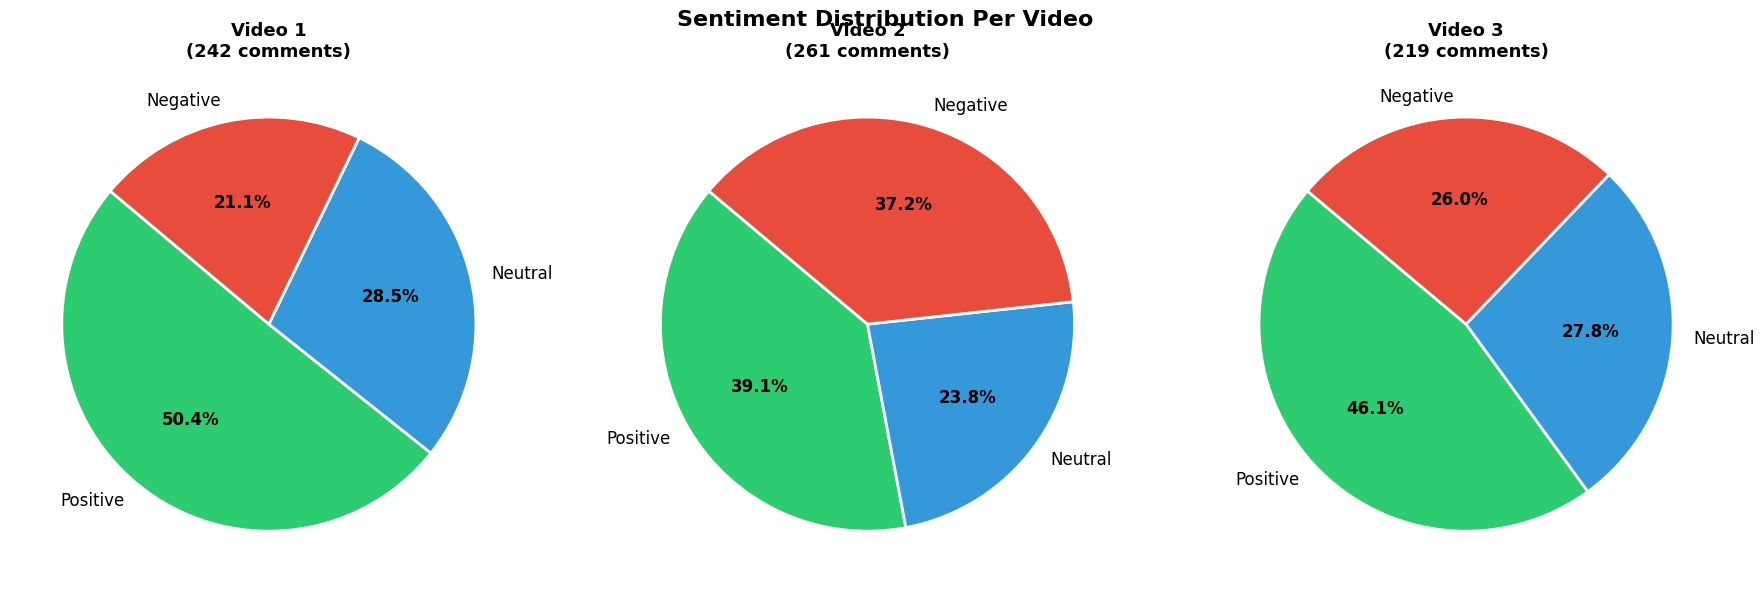

✅ Saved: sentiment_pie_charts.png


In [ ]:
# @title 🥧 Cell 9 — Visualization: Pie Charts Per Video

n = len(episode_results)
fig, axes = plt.subplots(1, n, figsize=(6*n, 6))
if n == 1: axes = [axes]
colors = ['#2ecc71', '#3498db', '#e74c3c']

for ax, result in zip(axes, episode_results):
    vals = [result['Positive %'], result['Neutral %'], result['Negative %']]
    lbls = ['Positive', 'Neutral', 'Negative']
    non_zero = [(v,l,c) for v,l,c in zip(vals,lbls,colors) if v > 0]
    if non_zero:
        v_, l_, c_ = zip(*non_zero)
        wedges, texts, autotexts = ax.pie(
            v_, labels=l_, colors=c_, autopct='%1.1f%%',
            startangle=140, textprops={'fontsize':12},
            wedgeprops={'edgecolor':'white','linewidth':2}
        )
        for at in autotexts: at.set_fontweight('bold')
    ax.set_title(f"{result['Video']}\n({result['Total Comments']} comments)",
                 fontsize=13, fontweight='bold')

fig.suptitle('Sentiment Distribution Per Video', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_pie_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: sentiment_pie_charts.png')

In [ ]:
# @title 🔥 Cell 10 — Groq Theme Clustering: Positive Comments Per Video

positive_themes_data = {}

for vd in video_data:
    print(f"\n{'='*65}")
    print(f"🔥 Positive Themes — {vd['label']} ({len(vd['pos_comments'])} comments)")
    print(f"{'='*65}")

    themes = cluster_with_groq(vd['pos_comments'], 'positive', batch_size=THEME_BATCH_SIZE)
    positive_themes_data[vd['label']] = themes

    if themes:
        df = pd.DataFrame([{
            'Theme': t['theme_name'],
            'Count': t.get('count', 0),
            'Summary': t['summary']
        } for t in themes])
        display(df)
    else:
        print('  No themes found.')


🔥 Positive Themes — Video 1 (122 comments)
  → Clustering 122 comments in 5 batches...
  → Theme batch 1/5... 6 themes found
  → Theme batch 2/5... 3 themes found
  → Theme batch 3/5... 4 themes found
  → Theme batch 4/5... 4 themes found
  → Theme batch 5/5... 2 themes found
  → Merging 19 raw themes...


,Theme,Count,Summary
0,Praise and Gratitude,29,Listeners express admiration and thanks to Ran...
1,Spiritual and Devotional Comments,17,Listeners express their devotion and gratitude...
2,Appreciation for Dhruva Prabhu and Podcast,16,Listeners appreciate Dhruva Prabhu's knowledge...
3,Request for Future Content,12,Listeners request specific topics and guests f...
4,Inspirational and Uplifting,10,Comments expressing gratitude and inspiration ...
5,Encouragement and Support,9,Viewers encourage Ranveer to continue his podc...
6,Guest Appreciation and Requests,8,Comments appreciating guests and requesting fu...
7,Miscellaneous,4,Comments that don't fit into other categories.



🔥 Positive Themes — Video 2 (102 comments)
  → Clustering 100 comments in 4 batches...
  → Theme batch 1/4... 4 themes found
  → Theme batch 2/4... 3 themes found
  → Theme batch 3/4... 4 themes found
  → Theme batch 4/4... 5 themes found
  → Merging 16 raw themes...


,Theme,Count,Summary
0,Suggestions and Feedback,30,"Viewers suggest topics, guests, and provide fe..."
1,Appreciation for the Podcast and Host,19,"Viewers appreciate the podcast, Ranveer, and h..."
2,Appreciation for Cycle Baba,18,Viewers praise Cycle Baba's work and personality.
3,Inspiration and Learning,15,Viewers find the podcast inspiring and informa...
4,General Praise and Encouragement,6,Viewers express enthusiasm and encouragement f...
5,Personal Connection and Gratitude,6,Viewers express personal connection and gratit...



🔥 Positive Themes — Video 3 (101 comments)
  → Clustering 100 comments in 4 batches...
  → Theme batch 1/4... 4 themes found
  → Theme batch 2/4... 3 themes found
  → Theme batch 3/4... 3 themes found
  → Theme batch 4/4... 4 themes found
  → Merging 14 raw themes...


,Theme,Count,Summary
0,Appreciation for Hosts and Guests,35,Hosts and guests are praised for their content...
1,Appreciation and Gratitude,20,Listeners express appreciation and gratitude t...
2,Inspiration and Motivation,12,Viewers find the podcast inspiring and motivat...
3,Personal Connection and Support,12,Listeners share personal connections and appre...
4,Wisdom and Insights,8,Listeners find the podcast's wisdom and insigh...
5,Request for More Content,8,"Listeners request more content, especially fro..."


In [ ]:
# @title ⚠️ Cell 11 — Groq Theme Clustering: Negative Comments Per Video

negative_themes_data = {}

for vd in video_data:
    print(f"\n{'='*65}")
    print(f"⚠️  Negative Themes — {vd['label']} ({len(vd['neg_comments'])} comments)")
    print(f"{'='*65}")

    themes = cluster_with_groq(vd['neg_comments'], 'negative', batch_size=THEME_BATCH_SIZE)
    negative_themes_data[vd['label']] = themes

    if themes:
        df = pd.DataFrame([{
            'Theme': t['theme_name'],
            'Count': t.get('count', 0),
            'Summary': t['summary']
        } for t in themes])
        display(df)
    else:
        print('  No themes found.')


⚠️  Negative Themes — Video 1 (51 comments)
  → Clustering 51 comments in 2 batches...
  → Theme batch 1/2... 4 themes found
  → Theme batch 2/2... 5 themes found
  → Merging 9 raw themes...


,Theme,Count,Summary
0,Appreciation and Feedback,26,Viewers appreciate the podcast and provide fee...
1,Guest Suggestions and Requests,13,Viewers suggest potential guests and request s...
2,Criticism of Content and Hosting,9,Viewers criticize the podcast's content choice...
3,Abrupt Ending and Episode Critique,8,Viewers express disappointment with the abrupt...



⚠️  Negative Themes — Video 2 (97 comments)
  → Clustering 95 comments in 4 batches...
  → Theme batch 1/4... 7 themes found
  → Theme batch 2/4... 5 themes found
  → Theme batch 3/4... 8 themes found
  → Theme batch 4/4... 2 themes found
  → Merging 22 raw themes...


,Theme,Count,Summary
0,Negative Feedback,30,Viewers are expressing their dislike and frust...
1,Positive Feedback and Appreciation,19,Viewers are expressing their love and apprecia...
2,Guest and Topic Suggestions,17,Viewers suggest guests or topics for future ep...
3,Suggestions for Improvement,13,Viewers offer suggestions for improving the po...
4,India vs China Comparison and Criticism,9,Viewers are disagreeing with the comparison be...
5,Host Interruptions and Style,6,Viewers are suggesting the host to improve his...
6,Audio Quality Issues,3,Viewers are complaining about low volume and p...
7,Sponsorship and Advertising,2,Viewers are unhappy with the amount of ads or ...



⚠️  Negative Themes — Video 3 (57 comments)
  → Clustering 56 comments in 2 batches...
  → Theme batch 1/2... 4 themes found
  → Theme batch 2/2... 4 themes found
  → Merging 8 raw themes...


,Theme,Count,Summary
0,Support and Enthusiasm,19,Support and enthusiasm for the podcast and Ran...
1,Support and Praise,12,Positive feedback and appreciation for the pod...
2,Negative Feedback,11,Criticism of the podcast or its hosts
3,Off-Topic Comments,5,Comments unrelated to the podcast
4,Personal Issues,4,Viewers sharing personal experiences or opinions
5,Invite New Guests,4,Request for new and interesting guests on the ...
6,Criticism of Ranveer,3,Criticism of Ranveer's behavior and podcast
7,Suggestions and Ideas,3,Suggestions for new podcast topics and ideas


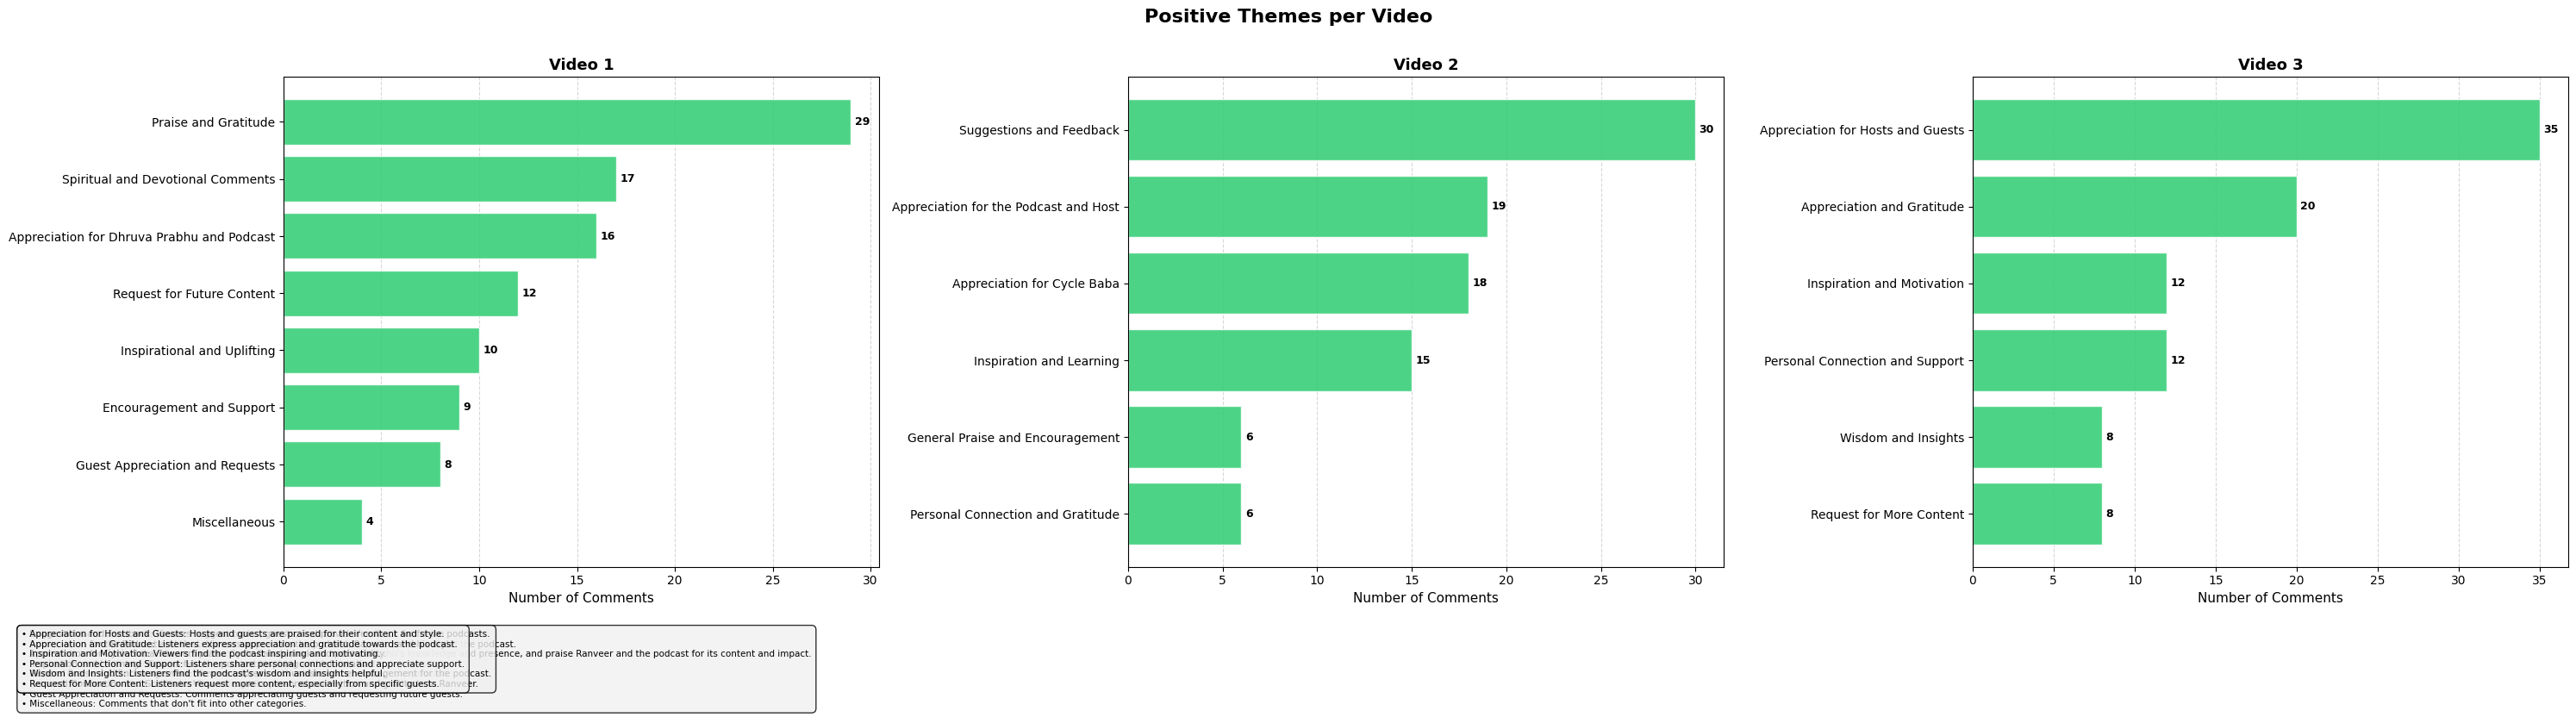

✅ Saved: positive_themes_per_video.png


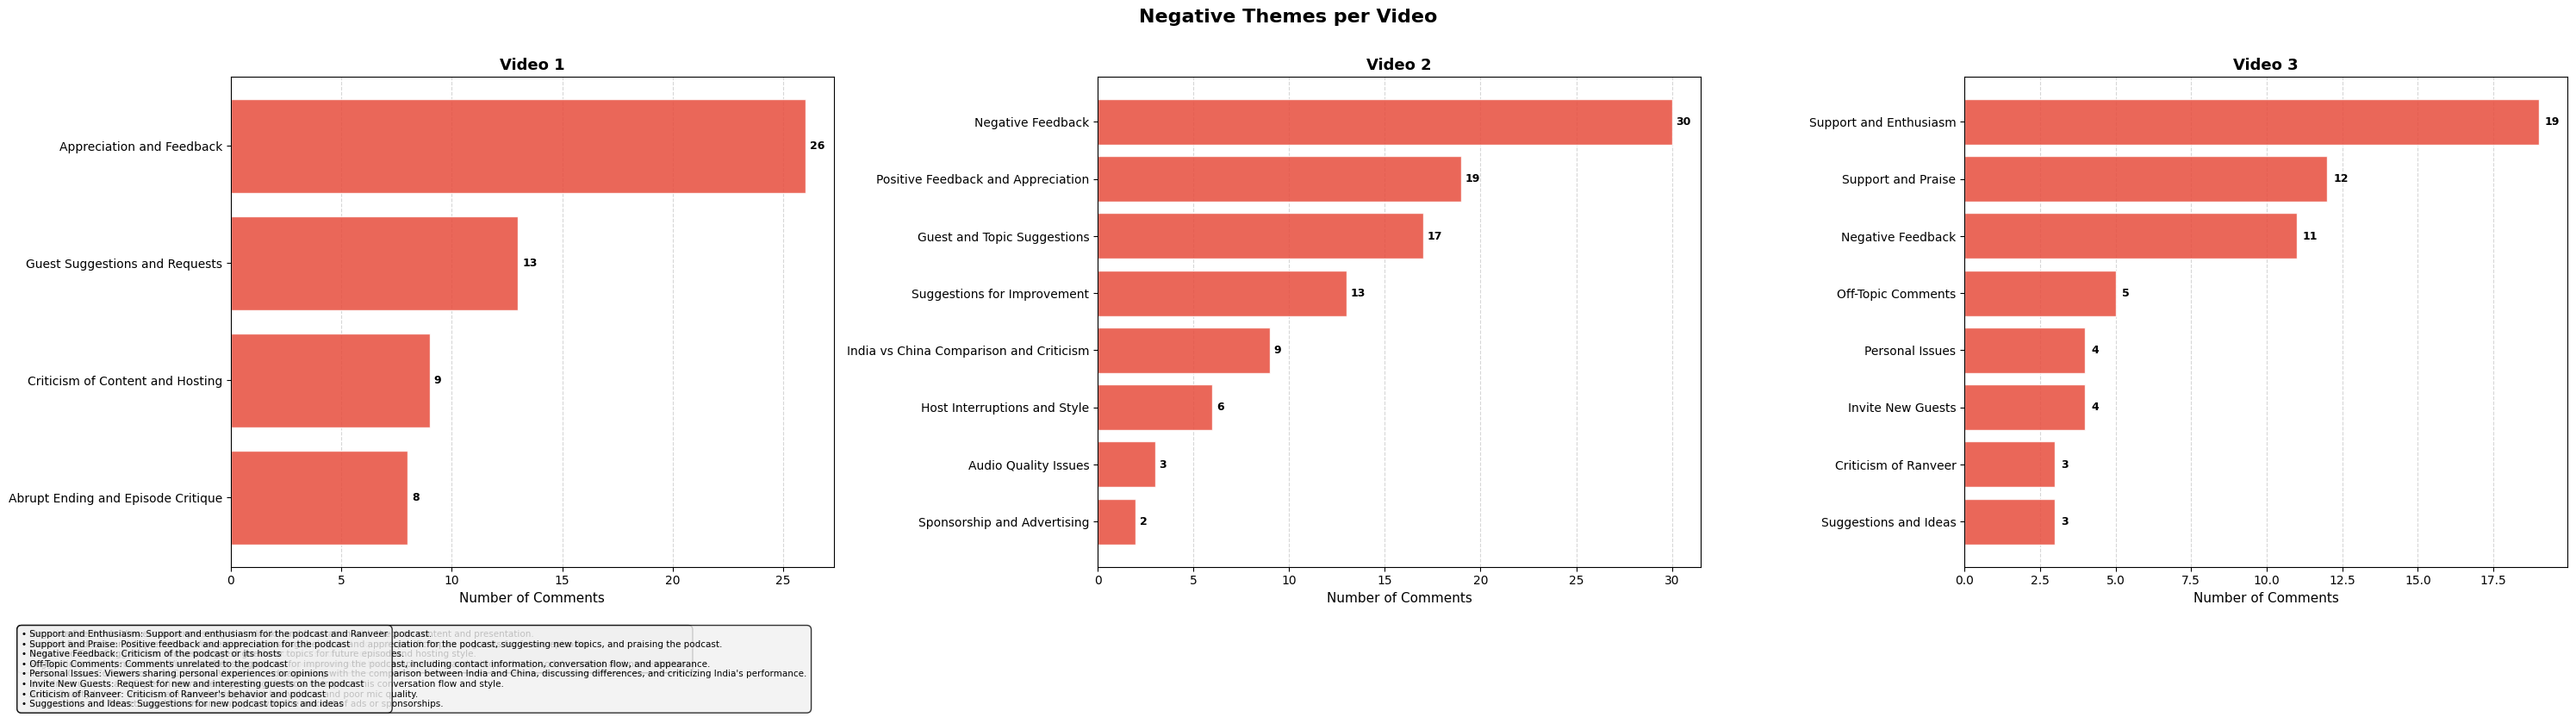

✅ Saved: negative_themes_per_video.png


In [ ]:
# @title 📈 Cell 12 — Visualization: Theme Bar Charts Per Video

def plot_theme_chart(themes_data, title, color):
    valid = {k: v for k, v in themes_data.items() if v}
    if not valid:
        print(f'No theme data for: {title}')
        return

    n = len(valid)
    fig, axes = plt.subplots(1, n, figsize=(10*n, 7))
    if n == 1: axes = [axes]
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.01)

    for ax, (vid_label, themes) in zip(axes, valid.items()):
        if not themes:
            ax.text(0.5, 0.5, 'No themes found', ha='center', va='center', fontsize=12)
            ax.set_title(vid_label, fontsize=13, fontweight='bold')
            continue

        sorted_themes = sorted(themes, key=lambda x: x.get('count', 0), reverse=True)[:8]
        names    = [t['theme_name'] for t in sorted_themes]
        counts   = [t.get('count', 0) for t in sorted_themes]
        summaries = [t['summary'] for t in sorted_themes]
        names = [n[:45]+'...' if len(n)>45 else n for n in names]

        y_pos = np.arange(len(names))
        bars = ax.barh(y_pos, counts, color=color, edgecolor='white', alpha=0.85)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(names, fontsize=10)
        ax.invert_yaxis()
        ax.set_xlabel('Number of Comments', fontsize=11)
        ax.set_title(vid_label, fontsize=13, fontweight='bold')
        ax.xaxis.grid(True, linestyle='--', alpha=0.5)
        ax.set_axisbelow(True)

        for bar, count in zip(bars, counts):
            ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
                    str(count), va='center', fontsize=9, fontweight='bold')

        # Summary box below chart
        summary_lines = '\n'.join([f'• {nm}: {sm}' for nm, sm in zip(names, summaries)])
        fig.text(0.01, -0.02, summary_lines, fontsize=7.5, va='top',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f0f0', alpha=0.8))

    plt.tight_layout()
    fname = re.sub(r'[^a-z0-9_]', '', title.lower().replace(' ','_')) + '.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {fname}')


plot_theme_chart(positive_themes_data, 'Positive Themes per Video', '#2ecc71')
plot_theme_chart(negative_themes_data, 'Negative Themes per Video', '#e74c3c')

In [ ]:
# @title 💾 Cell 13 — Export Everything & Download
from google.colab import files

comparison_df.to_csv('episode_sentiment_summary.csv', index=False)
print('✅ Saved: episode_sentiment_summary.csv')

for vid_label, themes in positive_themes_data.items():
    if themes:
        fname = f"{vid_label.replace(' ','_')}_positive_themes.csv"
        pd.DataFrame([{'Theme': t['theme_name'], 'Count': t.get('count',0),
                        'Summary': t['summary']} for t in themes]).to_csv(fname, index=False)
        print(f'✅ Saved: {fname}')

for vid_label, themes in negative_themes_data.items():
    if themes:
        fname = f"{vid_label.replace(' ','_')}_negative_themes.csv"
        pd.DataFrame([{'Theme': t['theme_name'], 'Count': t.get('count',0),
                        'Summary': t['summary']} for t in themes]).to_csv(fname, index=False)
        print(f'✅ Saved: {fname}')

print('\n📥 Downloading all files...')
for f in glob.glob('*.csv') + glob.glob('*.png'):
    files.download(f)

print('\n✅ Done!')